# Importation

Import rasters and vectors from file

## Settings

In [17]:
# Load packages
suppressPackageStartupMessages({
  library(terra)
})

# Parameters
param_subds <- NULL
param_lyrs <- NULL
param_crs <- ""
param_type <- ""
param_geometry <- ""
param_keep <- ""
param_out <- tempdir()

# Paths for examples
in_raster <- system.file("ex/elev.tif", package = "terra")
in_vector <- system.file("ex/lux.shp", package = "terra")

## Import raster from file

In [7]:
# GSTB import raster
# NaaVRE:
#  cell:
#   inputs:
#    - in_raster: String
#   params:
#    - param_subds: List
#    - param_lyrs: List
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# File path to be converted to raster
x <- in_raster

# Import raster
r <- rast(x     = x,
          subds = param_subds,
          lyrs  = param_lyrs)

# Save to file
writeRaster(x         = r,
            filename  = paste0(param_out, "/imported_raster.tif"),
            overwrite = TRUE)

# Output
out <- list.files(path       = param_out,
                  pattern    = "imported_raster.tif",
                  full.names = TRUE)

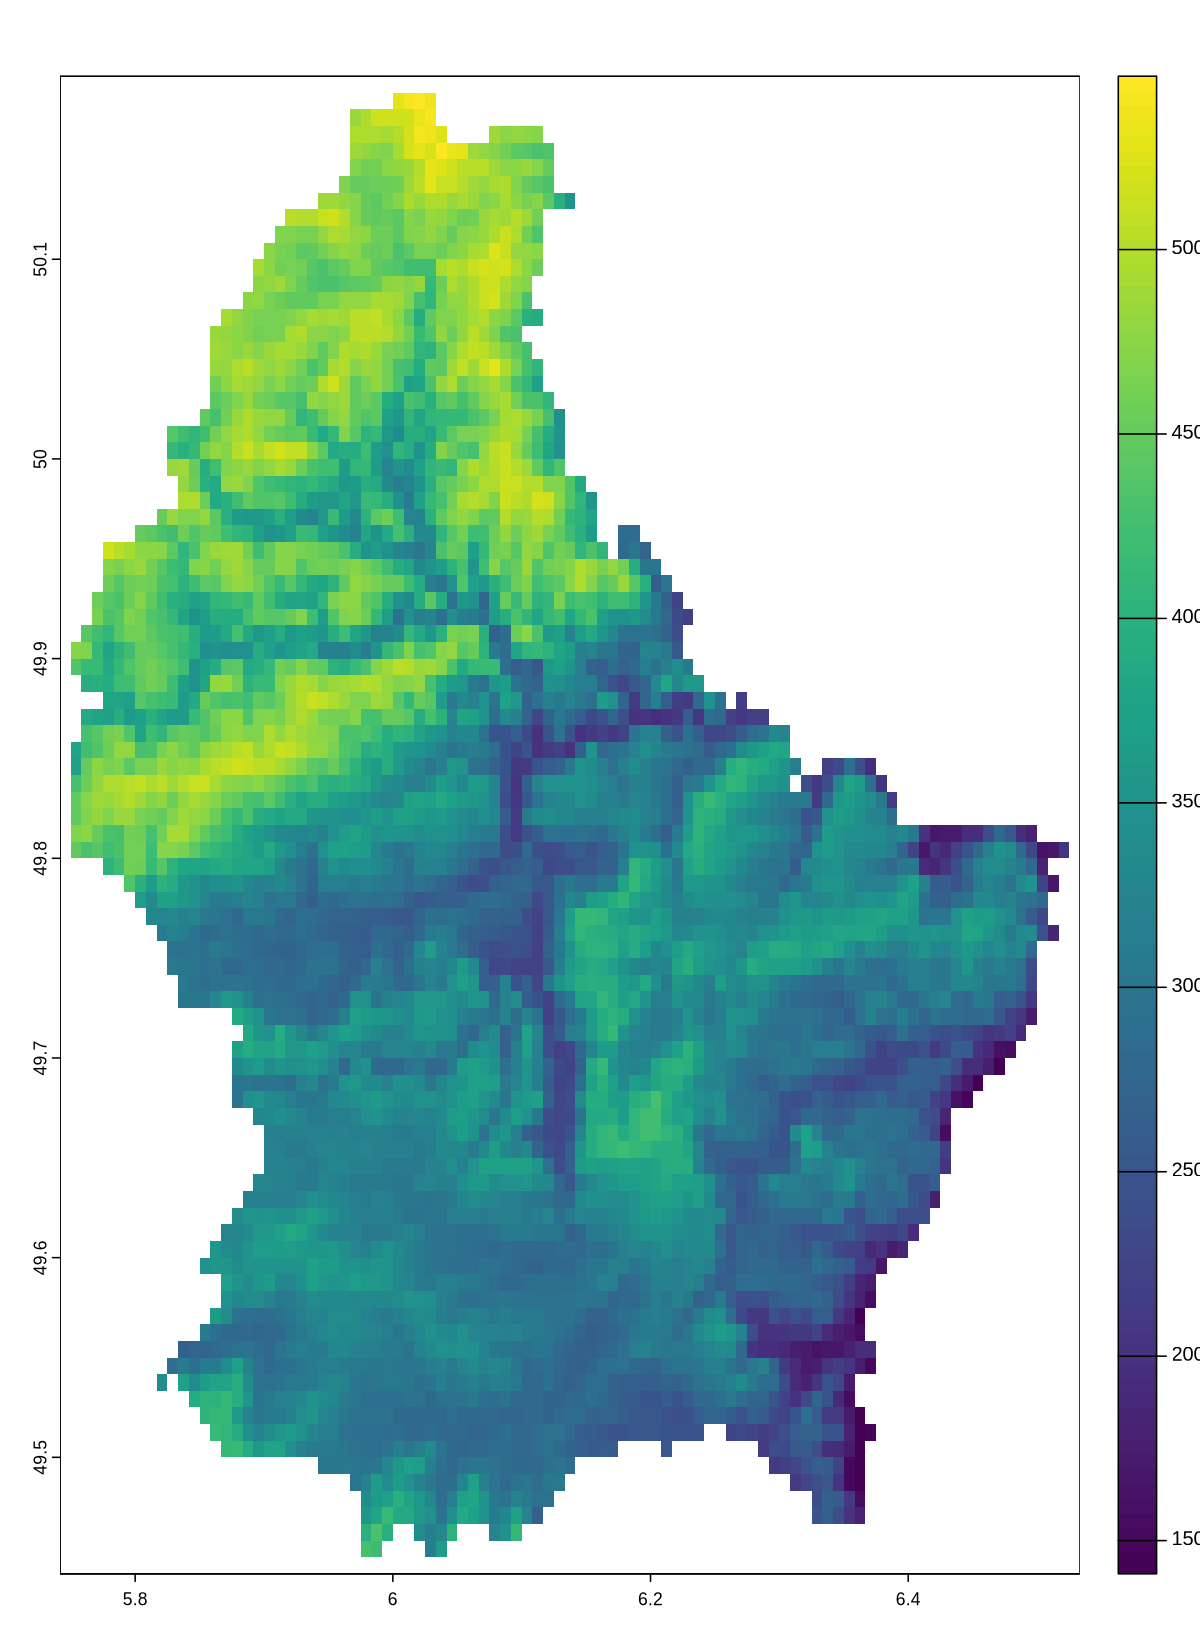

In [8]:
options(repr.plot.width = 8,
        repr.plot.height = 11,
        repr.plot.res = 150)
plot(rast(out))

## Import vector from file

In [18]:
# GSTB import vector
# NaaVRE:
#  cell:
#   inputs:
#    - in_vector: String
#   params:
#    - param_crs: String
#    - param_type: String
#    - param_geometry: List
#    - param_keep: Sring
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# Import vector
if(is.null(param_crs) | (param_crs == "")) {
  
  ## If CRS is NOT provided
  v <- vect(in_vector)

} else {
  
  ## If CRS is provided
  if(!is.null(param_type) & (param_type != "")) {
    
    ### If the type of geometry is provided (e.g. "points", "lines", "polygons")
    v <- vect(in_vector, type = param_type, crs = param_crs)
  
  } else if(!is.null(param_geometry) & (param_geometry != "")) {
    
    ### If names of fields with geometry are provided
    if(!is.null(param_keep) & !(param_keep %in% c("FALSE", "false", "NO", "No", "no"))) {
      
      #### If geometry is to be kept
      v <- vect(in_vector,
                geom = param_geometry,
                crs = param_crs,
                keepgeom = TRUE,
                quiet = TRUE)
    
    } else {
      
      #### If geometry is NOT to be kept
      v <- vect(in_vector,
                geom = param_geometry,
                crs = param_crs,
                keepgeom = FALSE,
                quiet = TRUE)
    }
  
  } else {
    
    ### If only CRS is provided
    v <- vect(in_vector,
              crs = param_crs)
  }
}

# Save to file
writeVector(x         = v,
            filename  = paste0(param_out, "/imported_vector.gpkg"),
            overwrite = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "imported_vector.gpkg",
                  full.names = TRUE)

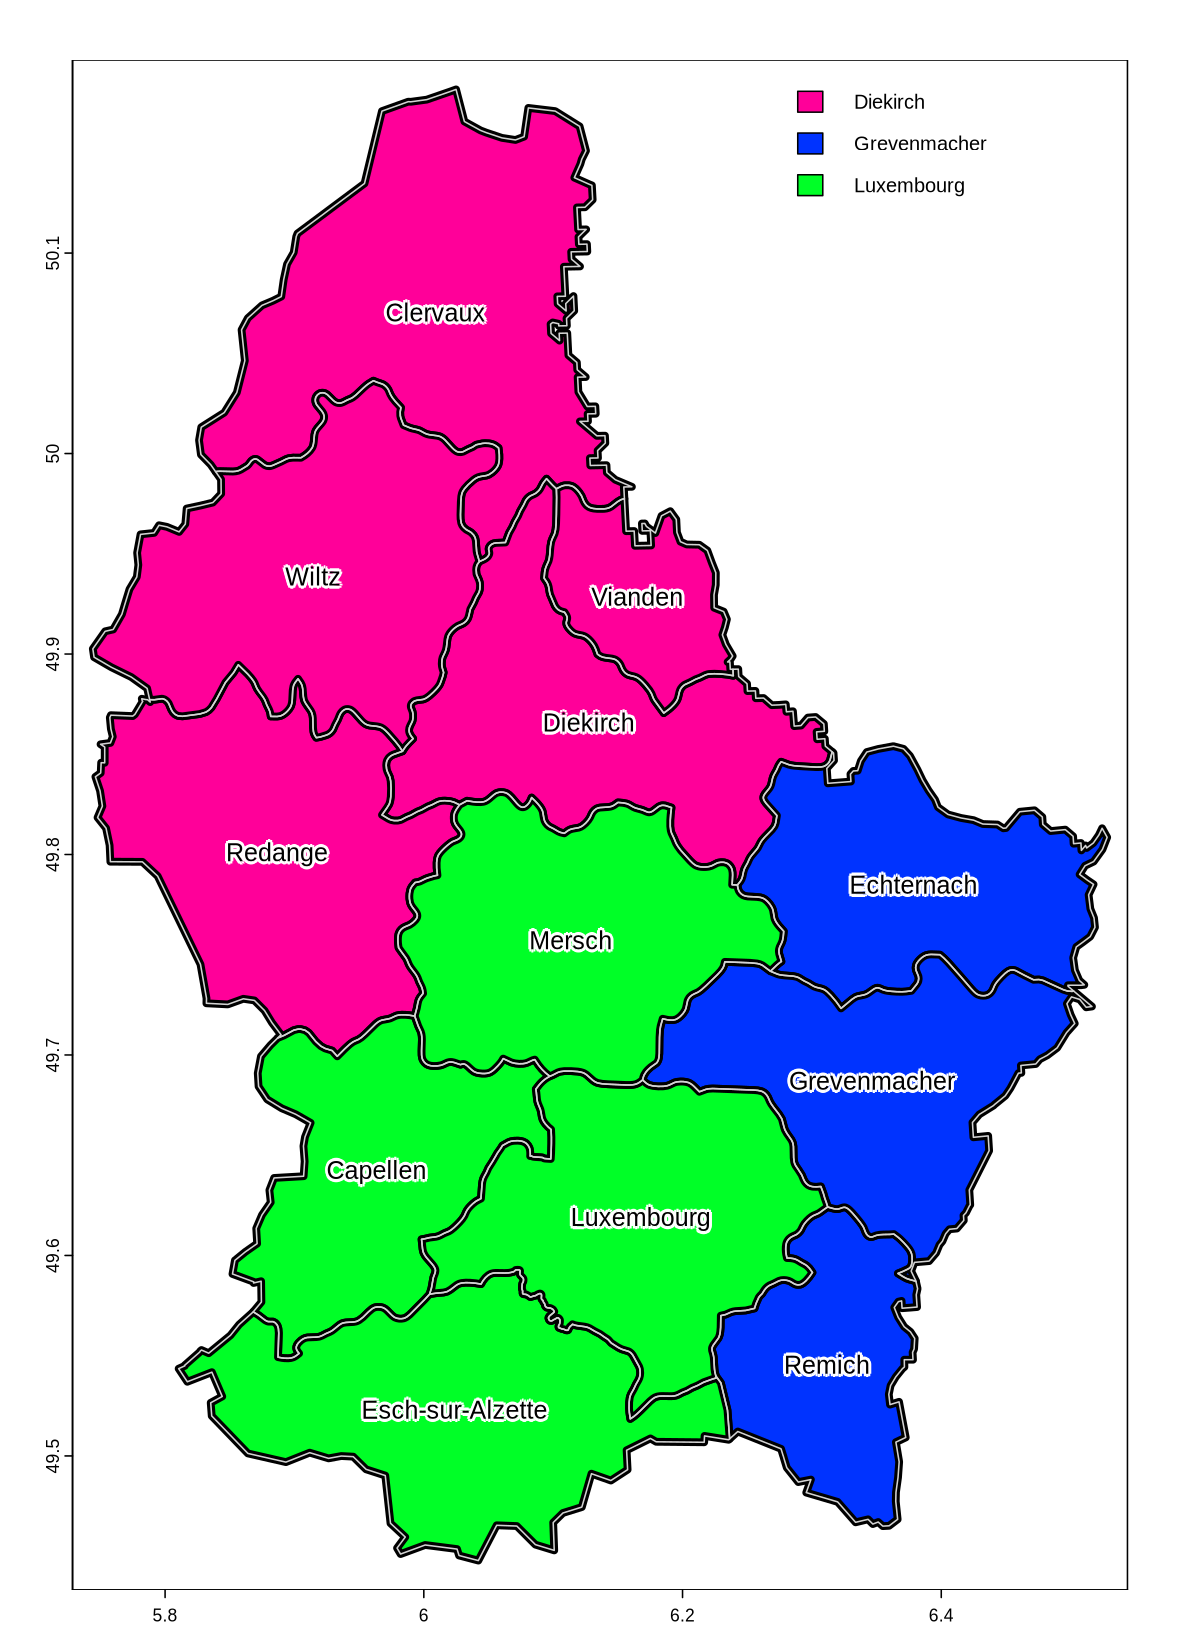

In [23]:
options(repr.plot.width = 8,
        repr.plot.height = 11,
        repr.plot.res = 150)
plot(vect(out), "NAME_1",
     lwd = 5, mar = rep(2, 4),
     plg = list(x = "topright"))
lines(vect(in_vector), lwd = 1, col = "light gray")
text(vect(in_vector), "NAME_2", halo = TRUE)